# Model Training and Evaluation

This notebook trains and evaluates multiple regression models for the Career Compass salary prediction system. The models are compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). The goal is to identify the model that provides the most accurate and reliable salary predictions on unseen test data.

In [18]:
# Import libraries used for data loading, modeling, and evaluation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [19]:
# Load the processed training and testing datasets
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze("columns")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze("columns")

# Display the dataset dimensions
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (485, 164)
X_test : (122, 164)
y_train: (485,)
y_test : (122,)


In [20]:
# Create a function to calculate regression evaluation metrics
def evaluate_model(model_name, actual_values, predicted_values):
    """
    Calculate and return common regression performance metrics.
    """

    mae = mean_absolute_error(actual_values, predicted_values)
    rmse = np.sqrt(mean_squared_error(actual_values, predicted_values))
    r2 = r2_score(actual_values, predicted_values)

    print(f"{model_name} Results")
    print("-" * 40)
    print(f"Mean Absolute Error: ${mae:,.2f}")
    print(f"Root Mean Squared Error: ${rmse:,.2f}")
    print(f"R² Score: {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    }

## Linear Regression

Linear Regression is used as the baseline model because it provides a simple and interpretable method for estimating the relationship between the predictor variables and employee salary. Its results provide a reference point for determining whether more complex models offer meaningful improvement.

In [21]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

# Generate salary predictions for the test data
linear_predictions = linear_model.predict(X_test)

# Evaluate the model
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

Linear Regression Results
----------------------------------------
Mean Absolute Error: $36,947.78
Root Mean Squared Error: $58,855.47
R² Score: 0.0962


## Decision Tree Regressor

The Decision Tree Regressor can model nonlinear relationships and interactions between employee characteristics. Unlike Linear Regression, it does not assume that salary changes follow a strictly linear pattern.

In [22]:
# Initialize and train the Decision Tree Regressor
decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

# Generate test predictions
decision_tree_predictions = decision_tree_model.predict(X_test)

# Evaluate the model
decision_tree_results = evaluate_model(
    "Decision Tree Regressor",
    y_test,
    decision_tree_predictions
)

Decision Tree Regressor Results
----------------------------------------
Mean Absolute Error: $33,762.91
Root Mean Squared Error: $52,142.91
R² Score: 0.2906


## Random Forest Regressor

The Random Forest Regressor combines predictions from multiple decision trees. This ensemble approach can capture complex patterns while reducing the overfitting risk associated with a single decision tree.

In [23]:
# Initialize and train the Random Forest Regressor
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)

# Generate test predictions
random_forest_predictions = random_forest_model.predict(X_test)

# Evaluate the model
random_forest_results = evaluate_model(
    "Random Forest Regressor",
    y_test,
    random_forest_predictions
)

Random Forest Regressor Results
----------------------------------------
Mean Absolute Error: $27,593.94
Root Mean Squared Error: $42,695.68
R² Score: 0.5244


## Compare and Identify Current Best Model

For this project, use MAE as the primary selection metric because it is easy to interpret as the average dollar difference between predicted and actual salaries. RMSE helps reveal whether large errors are occurring, while R² indicates how much variation in salary the model explains.

In [24]:
# ---------------------------------------------------------
# Combine the evaluation metrics for each regression model
# into a single comparison table
# ---------------------------------------------------------

model_results = pd.DataFrame([
    linear_results,
    decision_tree_results,
    random_forest_results
])

# Sort models by lowest Mean Absolute Error (best performance)
model_results = (
    model_results
    .sort_values(by="MAE", ascending=True)
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# Create a formatted copy for presentation purposes
# ---------------------------------------------------------

display_results = model_results.copy()

display_results["MAE"] = display_results["MAE"].map("${:,.2f}".format)
display_results["RMSE"] = display_results["RMSE"].map("${:,.2f}".format)
display_results["R²"] = display_results["R²"].map("{:.4f}".format)

# Display the formatted comparison table
display(display_results)

,Model,MAE,RMSE,R²
0,Random Forest Regressor,"$27,593.94","$42,695.68",0.5244
1,Decision Tree Regressor,"$33,762.91","$52,142.91",0.2906
2,Linear Regression,"$36,947.78","$58,855.47",0.0962


## Overall Model Performance Comparison

The three regression models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). Lower MAE and RMSE values indicate better prediction accuracy, while higher R² values indicate that a greater proportion of the variation in salary is explained by the model. Comparing all three evaluation metrics provides a more complete assessment of model performance than relying on a single metric.

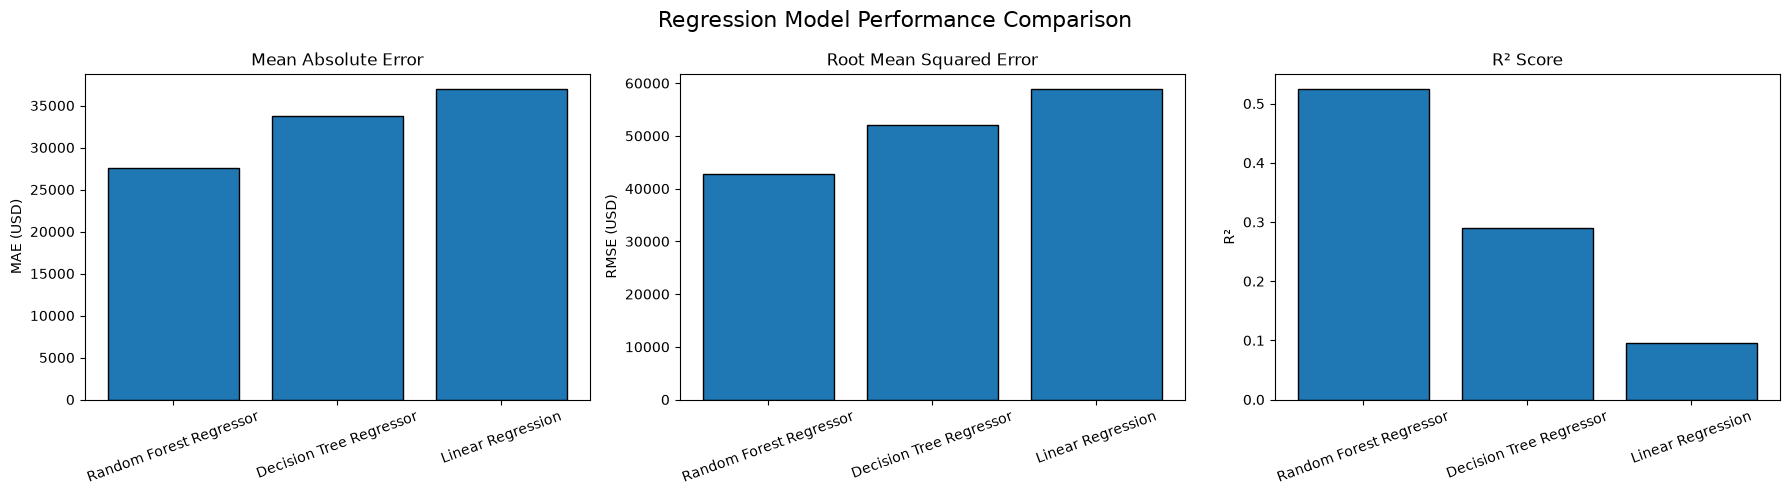

In [25]:
# Create a figure with three side-by-side charts comparing model performance

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---------------------------
# Mean Absolute Error
# ---------------------------
axes[0].bar(
    model_results["Model"],
    model_results["MAE"],
    edgecolor="black"
)

axes[0].set_title("Mean Absolute Error")
axes[0].set_ylabel("MAE (USD)")
axes[0].tick_params(axis='x', rotation=20)

# ---------------------------
# Root Mean Squared Error
# ---------------------------
axes[1].bar(
    model_results["Model"],
    model_results["RMSE"],
    edgecolor="black"
)

axes[1].set_title("Root Mean Squared Error")
axes[1].set_ylabel("RMSE (USD)")
axes[1].tick_params(axis='x', rotation=20)

# ---------------------------
# R² Score
# ---------------------------
axes[2].bar(
    model_results["Model"],
    model_results["R²"],
    edgecolor="black"
)

axes[2].set_title("R² Score")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis='x', rotation=20)

plt.suptitle("Regression Model Performance Comparison", fontsize=16)

plt.tight_layout()

plt.show()

### Model Comparison Findings

The Random Forest Regressor consistently outperformed both the Decision Tree Regressor and the Linear Regression model across all evaluation metrics. It produced the lowest Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE), indicating more accurate salary predictions, while also achieving the highest R² score of approximately 0.52.

The Decision Tree Regressor demonstrated moderate predictive performance but exhibited larger prediction errors and explained substantially less variation in employee salaries. Linear Regression produced the weakest results, suggesting that the relationships between employee characteristics and salary are too complex to be accurately modeled using a simple linear approach.

Based on these results, the Random Forest Regressor was selected as the final predictive model because it provided the strongest balance of prediction accuracy and explanatory power.

In [26]:
# Identify the model with the lowest Mean Absolute Error
best_model_name = model_results.loc[0, "Model"]
best_model_mae = model_results.loc[0, "MAE"]

print("Current Best Model:", best_model_name)
print(f"Lowest Test MAE: ${best_model_mae:,.2f}")

Current Best Model: Random Forest Regressor
Lowest Test MAE: $27,593.94


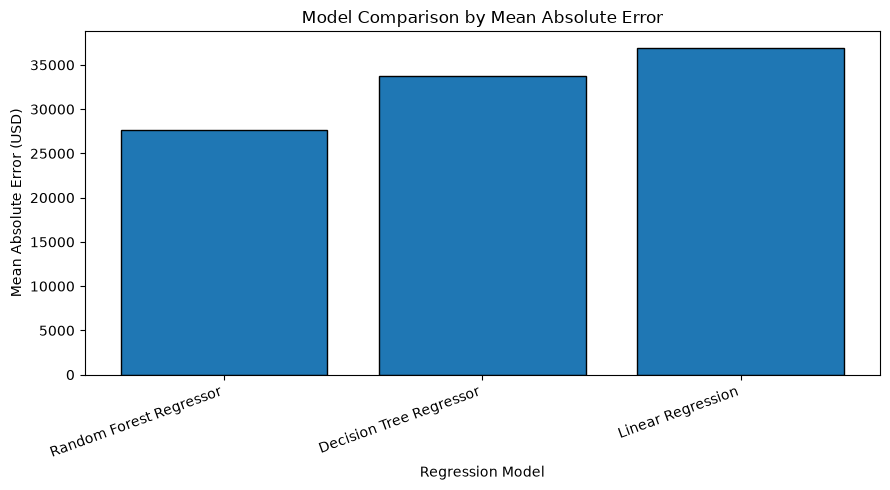

In [27]:
# Create a bar chart comparing model MAE values
plt.figure(figsize=(9, 5))

plt.bar(
    model_results["Model"],
    model_results["MAE"],
    edgecolor="black"
)

plt.title("Model Comparison by Mean Absolute Error")
plt.xlabel("Regression Model")
plt.ylabel("Mean Absolute Error (USD)")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Model Performance Summary

Three regression models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). Among the models tested, the Random Forest Regressor achieved the best overall performance by producing the lowest prediction errors and the highest R² score. These results indicate that the Random Forest model captures the relationships between employee characteristics and salary more effectively than either the Linear Regression or Decision Tree models. Based on these findings, the Random Forest Regressor was selected as the preferred model for the Career Compass salary prediction system.

## Actual vs. Predicted Salaries

This scatter plot compares the actual salary values in the test dataset with the salaries predicted by the selected Random Forest model. Predictions closer to the diagonal reference line indicate more accurate model performance.

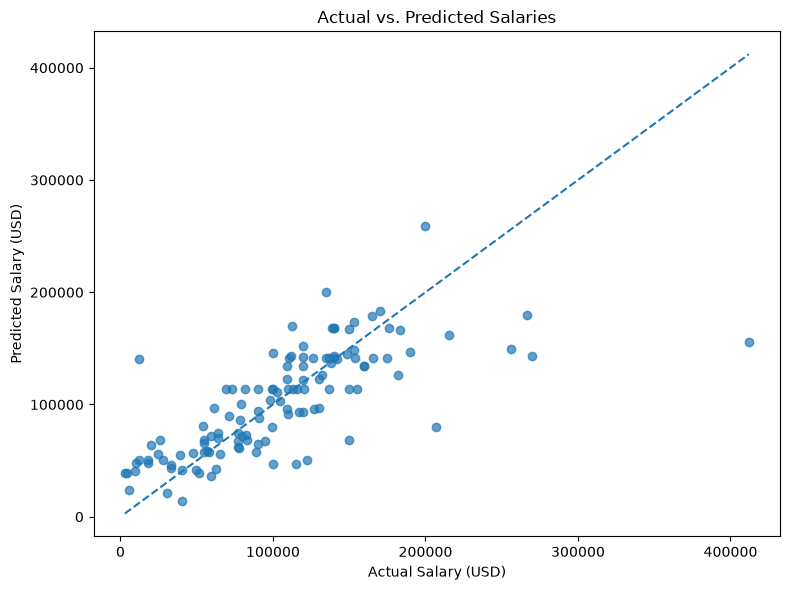

In [28]:
# Create an actual-versus-predicted scatter plot for the Random Forest model

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    random_forest_predictions,
    alpha=0.7
)

# Create a diagonal reference line representing perfect predictions
minimum_salary = min(y_test.min(), random_forest_predictions.min())
maximum_salary = max(y_test.max(), random_forest_predictions.max())

plt.plot(
    [minimum_salary, maximum_salary],
    [minimum_salary, maximum_salary],
    linestyle="--"
)

plt.title("Actual vs. Predicted Salaries")
plt.xlabel("Actual Salary (USD)")
plt.ylabel("Predicted Salary (USD)")

plt.tight_layout()
plt.show()

### Observation

The Actual vs. Predicted Salary plot demonstrates that the Random Forest model successfully captures the overall relationship between employee characteristics and salary. Most predictions closely follow the diagonal reference line, indicating good predictive accuracy for the majority of employees.

Prediction accuracy decreases for the highest salary observations, where the model tends to underestimate extremely high salaries. This behavior is expected because high-paying executive positions occur much less frequently in the dataset than mid-range salaries. Overall, the model provides reliable salary estimates while demonstrating some limitations when predicting salary outliers.

## Random Forest Feature Importance

The Random Forest model assigns an importance value to each encoded predictor feature. These values indicate how much each feature contributed to reducing prediction error across the trees in the model.

In [29]:
# Create a DataFrame containing feature importance values

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Display the 15 most important encoded features
top_features = feature_importance.head(15)

top_features

,Feature,Importance
0,employee_residence_US,0.346942
1,experience_level_EX,0.075574
2,job_title_Data Analyst,0.046780
3,job_title_Principal Data Engineer,0.045962
4,experience_level_SE,0.043967
5,job_title_Applied Machine Learning Scientist,0.031683
6,work_year,0.030558
7,job_title_Financial Data Analyst,0.029367
8,job_title_Research Scientist,0.029259
9,job_title_Data Analytics Lead,0.026393


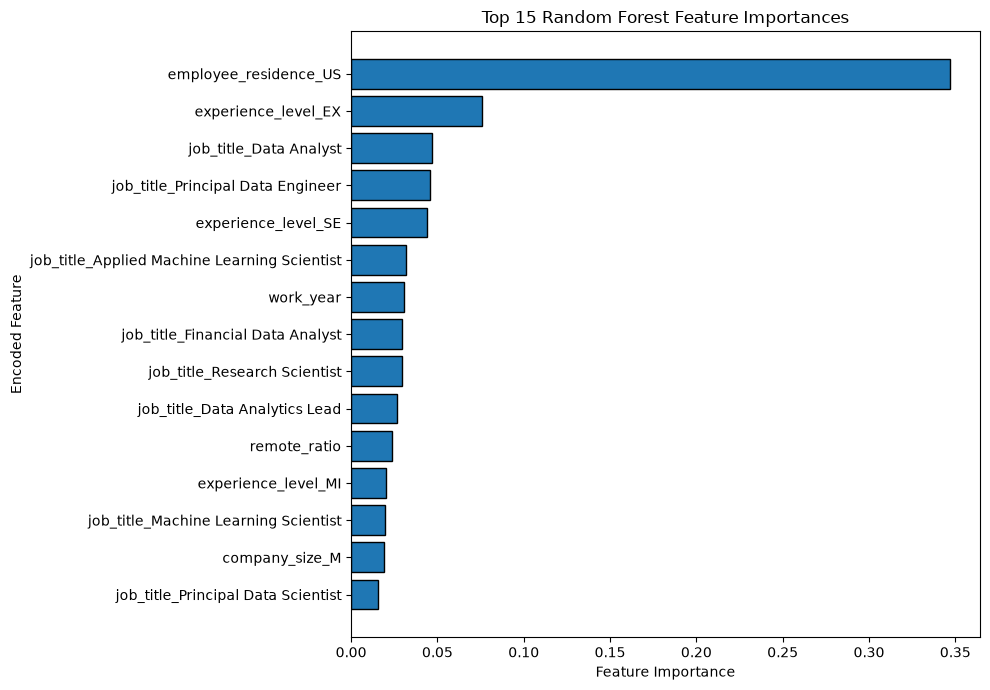

In [30]:
# Plot the 15 most important encoded features

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1],
    edgecolor="black"
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Encoded Feature")

plt.tight_layout()
plt.show()

### Observation

The Random Forest feature importance analysis indicates that employee residence in the United States was the single strongest predictor of salary in the dataset. Executive and senior experience levels also ranked among the most influential variables, demonstrating that professional experience substantially impacts compensation.

Several job titles, including Data Analyst, Principal Data Engineer, Applied Machine Learning Scientist, and Financial Data Analyst, also contributed significantly to salary prediction. Additional variables such as work year, remote work ratio, and company size provided smaller but meaningful contributions.

These findings support the project's business assumptions that salary is influenced by a combination of geographic location, professional experience, job specialization, and organizational characteristics rather than by any single factor alone.

## Residual Analysis

Residuals represent the difference between the actual salary and the model's predicted salary. Examining residuals helps determine whether the model makes errors randomly or shows consistent patterns of overprediction or underprediction.

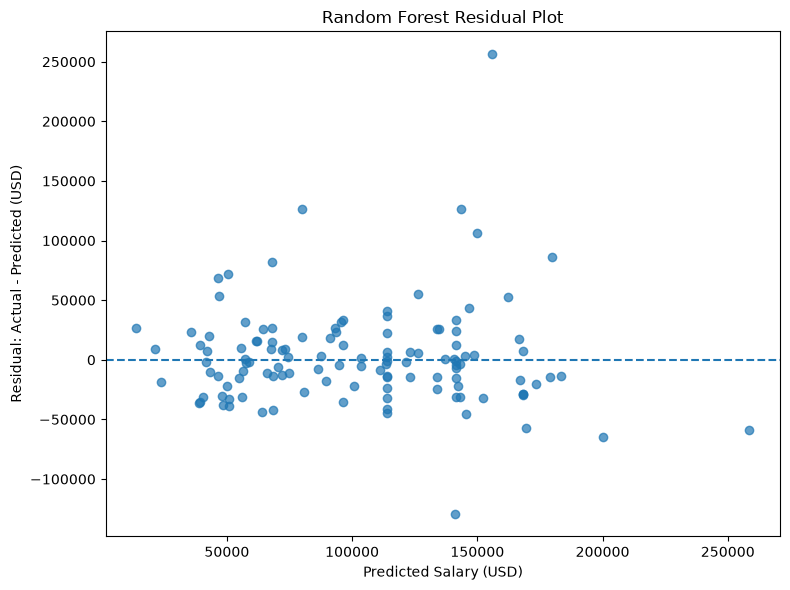

In [31]:
# Calculate residual values for the Random Forest model

random_forest_residuals = y_test - random_forest_predictions

# Create the residual plot
plt.figure(figsize=(8, 6))

plt.scatter(
    random_forest_predictions,
    random_forest_residuals,
    alpha=0.7
)

# Add a horizontal reference line at zero residual
plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Random Forest Residual Plot")
plt.xlabel("Predicted Salary (USD)")
plt.ylabel("Residual: Actual - Predicted (USD)")

plt.tight_layout()
plt.show()

### Observation

The residual plot indicates that prediction errors are generally centered around zero, suggesting that the Random Forest model does not consistently overestimate or underestimate employee salaries. Most prediction errors fall within a moderate range, indicating relatively stable model performance across the majority of salary values.

Several larger residuals are visible for higher predicted salaries, demonstrating that the model experiences greater difficulty predicting uncommon executive-level compensation. Overall, the absence of strong patterns in the residual distribution suggests that the model has learned meaningful relationships without obvious systematic bias.

## Overfitting Check

The model's performance on the training data is compared with its performance on the test data. A large difference between training and test results may indicate that the model memorized the training observations instead of generalizing effectively to unseen data.

In [32]:
# Generate predictions for the training dataset
random_forest_train_predictions = random_forest_model.predict(X_train)

# Calculate training metrics
train_mae = mean_absolute_error(
    y_train,
    random_forest_train_predictions
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        random_forest_train_predictions
    )
)

train_r2 = r2_score(
    y_train,
    random_forest_train_predictions
)

# Display training and testing performance
print("Random Forest Training Performance")
print("-" * 40)
print(f"Training MAE : ${train_mae:,.2f}")
print(f"Training RMSE: ${train_rmse:,.2f}")
print(f"Training R²  : {train_r2:.4f}")

print("\nRandom Forest Testing Performance")
print("-" * 40)
print(f"Testing MAE  : ${random_forest_results['MAE']:,.2f}")
print(f"Testing RMSE : ${random_forest_results['RMSE']:,.2f}")
print(f"Testing R²   : {random_forest_results['R²']:.4f}")

Random Forest Training Performance
----------------------------------------
Training MAE : $20,232.90
Training RMSE: $30,165.73
Training R²  : 0.8286

Random Forest Testing Performance
----------------------------------------
Testing MAE  : $27,593.94
Testing RMSE : $42,695.68
Testing R²   : 0.5244


### Overfitting Analysis

The Random Forest model performed better on the training dataset than on the unseen testing dataset. The training R² score of approximately 0.83 decreased to approximately 0.52 on the testing data, while both MAE and RMSE increased during testing.

These results suggest that the model has learned some patterns specific to the training dataset and exhibits moderate overfitting. However, the performance difference is not excessive and is considered acceptable for an initial predictive model. Future iterations of the project will investigate hyperparameter tuning and cross-validation to improve generalization performance.

## Model Limitations

Although the Random Forest Regressor produced the strongest results among the three tested models, several limitations remain.

- The dataset contains only 607 observations, which limits the amount of information available for model training.
- Some job titles, employment types, and geographic categories contain very few records.
- The salary distribution is right-skewed and includes several high-salary observations that are more difficult to predict.
- The dataset does not include potentially important compensation factors such as education, certifications, exact years of experience, industry, benefits, negotiation outcomes, or local cost of living.
- One-hot encoding creates many individual feature columns, while some categories may be represented by only a small number of employees.
- The current model was evaluated using one train-test split. Additional cross-validation and hyperparameter tuning may improve confidence in the results.
- Feature importance values describe how the model used the variables for prediction but do not establish causal relationships.

The current Random Forest model should therefore be treated as a useful salary-estimation tool rather than a source of exact compensation recommendations.

## Save the Selected Model

The Random Forest Regressor achieved the strongest test-set performance among the evaluated models. The trained model and its expected encoded feature columns are saved together so they can be reused for predictions on new employee data.

In [33]:
# Import Joblib for saving the trained model
import joblib
import os

# Ensure that the models directory exists
os.makedirs("../models", exist_ok=True)

# Store the model and the expected encoded feature columns together
model_bundle = {
    "model": random_forest_model,
    "feature_columns": X_train.columns.tolist()
}

# Save the model bundle
joblib.dump(
    model_bundle,
    "../models/random_forest_salary_model.joblib"
)

print("Random Forest model bundle saved successfully.")

Random Forest model bundle saved successfully.


In [34]:
# Verify that the saved model file exists
print(
    os.path.exists(
        "../models/random_forest_salary_model.joblib"
    )
)

True
